In [33]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay                         

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams



#### What is HC0_SE ?

heteroscedasticity-consistent (HC) standard error estimator, which ***corrects for heteroscedasticity (unequal error variances) in regression models*** but is known to be asymptotically biased and downwardly biased in small samples. 

other estimators like HC1, HC2, or HC3, especially when sample sizes are small. 

**Qus: What are Heteroscedasticity-Consistent Standard Errors?** 

- They are used when the assumption of homoscedasticity (constant error variance) in OLS regression is violated, a condition called heteroscedasticity.
- HC standard errors allow you to perform valid statistical inference even when error variances are not constant.
- They are also known as robust standard errors, Eicker-Huber-White standard errors, or White standard errors.

**Qus: Why is HC0 not preferred?**

Asymptotic bias:

The HC0 estimator is based on the asymptotic version of the estimator and does not account for small-sample bias. [In the context of regressions, asymptotic bias refers to the behavior of an estimator as the sample size approaches infinity.]

Downward bias:
In practice, HC0 is often downwardly biased, leading to overconfident results and potentially incorrect inferences, especially in samples with 250 or fewer observations. 

Simplicity vs. Accuracy:
While HC0 is the simplest form to understand and compute, it sacrifices accuracy for small sample sizes. 

### Superior Alternatives

HC1:
A simple improvement over HC0 that includes a correction for degrees of freedom but is still an asymptotic estimator and not the best choice for small samples. 
HC2 and HC3:
These are considered superior estimators that provide better small-sample corrections and are less sensitive to outliers. HC3, in particular, is recommended for its robustness even in very small samples.

### How to choose HC0/1/2/3 ?

- Use HC3 (or other, more robust variants) instead of HC0 for small-sample corrections. 
- When you suspect heteroscedasticity, you should use a heteroscedasticity-consistent estimator like HC3 rather than relying on classical standard errors. 



In [34]:
path = r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\Notes\Ch-5-TRANSFORMATIONS AND WEIGHTING TO CORRECT\galton.txt'
df = pd.read_csv(path)

X = df['Parent']
y = df['Progeny']
X = sm.add_constant(X)

In [35]:
weights = 1 / np.square(df['SD'])
mod_wls = sm.WLS(y, X, weights=weights)
res_wls = mod_wls.fit()
#print(res_wls.summary())

In [36]:
res_ols = sm.OLS(y, X).fit()
#print(res_ols.summary())

In [37]:
res_HC = sm.OLS(y, X).fit(cov_type= 'HC1')

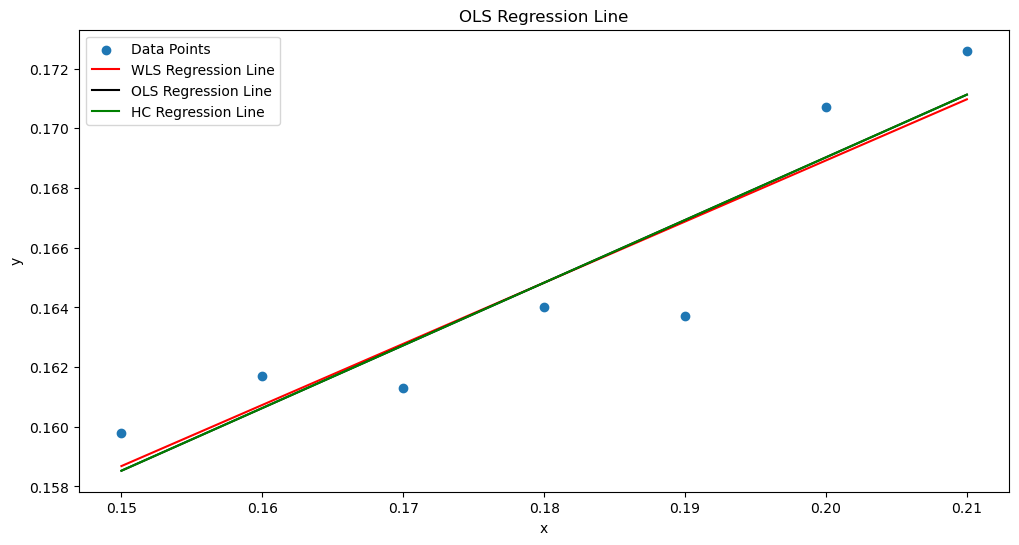

In [38]:
x_true = df['Parent']
y_true = y
y_predicted_wls = res_wls.predict(X)
y_predicted_ols = res_ols.predict(X)
y_predicted_hc  = res_HC.predict(X)

plt.figure(figsize=(12, 6))
plt.scatter(x_true, y_true, label='Data Points')
plt.plot(x_true, y_predicted_wls, color='red', label='WLS Regression Line')
plt.plot(x_true, y_predicted_ols, color='black', label='OLS Regression Line')
plt.plot(x_true, y_predicted_hc, color='green', label='HC Regression Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('OLS Regression Line')
plt.show()